# Building a Decision Tree: Play Tennis

In this notebook, we build a Decision Tree classifier to determine whether to play tennis based on weather conditions. We will use `OrdinalEncoder` to directly handle the categorical text data without tedious manual preprocessing.

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import OrdinalEncoder

# 1. Create the Play Tennis dataset
data = {
    'Outlook': ['Sunny', 'Sunny', 'Overcast', 'Rain', 'Rain', 'Rain', 'Overcast', 'Sunny', 'Sunny', 'Rain', 'Sunny', 'Overcast', 'Overcast', 'Rain'],
    'Temperature': ['Hot', 'Hot', 'Hot', 'Mild', 'Cool', 'Cool', 'Cool', 'Mild', 'Cool', 'Mild', 'Mild', 'Mild', 'Hot', 'Mild'],
    'Humidity': ['High', 'High', 'High', 'High', 'Normal', 'Normal', 'Normal', 'High', 'Normal', 'Normal', 'Normal', 'High', 'Normal', 'High'],
    'Wind': ['Weak', 'Strong', 'Weak', 'Weak', 'Weak', 'Strong', 'Strong', 'Weak', 'Weak', 'Weak', 'Strong', 'Strong', 'Weak', 'Strong'],
    'Play Tennis': ['No', 'No', 'Yes', 'Yes', 'Yes', 'No', 'Yes', 'No', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'No']
}

df = pd.DataFrame(data)
display(df.head())

,Outlook,Temperature,Humidity,Wind,Play Tennis
0,Sunny,Hot,High,Weak,No
1,Sunny,Hot,High,Strong,No
2,Overcast,Hot,High,Weak,Yes
3,Rain,Mild,High,Weak,Yes
4,Rain,Cool,Normal,Weak,Yes


In [13]:
# 2. Direct Categorical Encoding and Model Training
# Scikit-Learn's Decision Trees require numeric features.
# We use OrdinalEncoder to seamlessly transform our text categories into numbers.

X = df.drop('Play Tennis', axis=1)
y = df['Play Tennis']

# Encode categorical features
encoder = OrdinalEncoder()
X_encoded = encoder.fit_transform(X)

# Initialize and train the Decision Tree classifier directly on the entire dataset
clf = DecisionTreeClassifier(criterion='entropy', random_state=42)
clf.fit(X_encoded, y)

print("Model trained successfully on encoded categorical data.")

Model trained successfully on encoded categorical data.


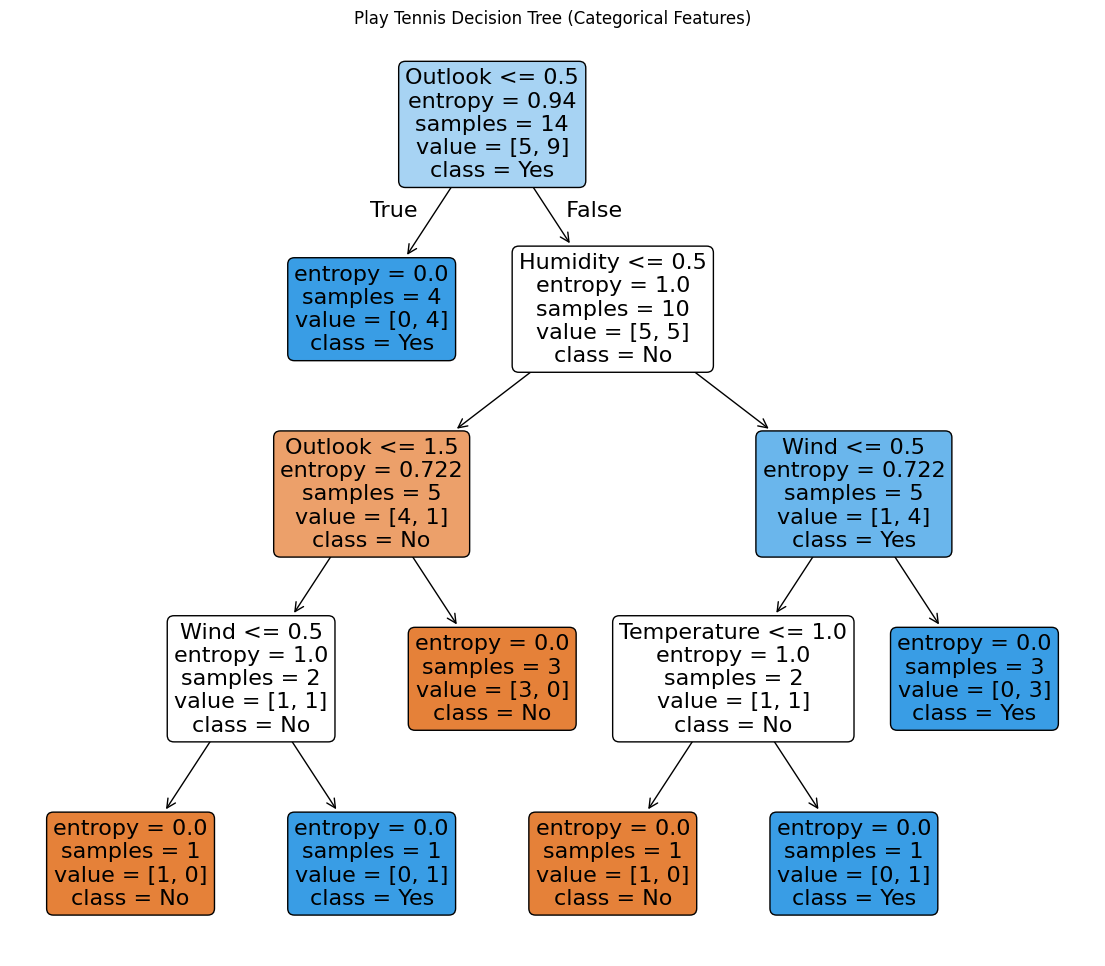

In [15]:
# 3. Visualizing the Decision Tree
plt.figure(figsize=(14, 12))
plot_tree(
    clf, 
    feature_names=X.columns,
    class_names=clf.classes_,
    filled=True, 
    rounded=True
)
plt.title("Play Tennis Decision Tree (Categorical Features)")
plt.show()